# LIFO.AI CSV Processing Demo

This notebook demonstrates the comprehensive CSV processing capabilities of LIFO.AI's unified processor.

## Features Demonstrated:
- ✅ Security validation and formula injection protection
- ✅ Intelligent column mapping and normalization
- ✅ Data cleaning and validation
- ✅ Category normalization and mapping
- ✅ Date parsing and validation
- ✅ Price validation and currency handling
- ✅ Comprehensive error handling and reporting
- ✅ Interactive visualizations of results

---

## 1. Setup and Configuration

First, let's set up our environment and import the necessary libraries.

In [7]:
# Environment setup
import sys
import os
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Add lifo-ai-core to path 
notebook_dir = os.path.dirname(os.path.abspath(''))
project_root = os.path.dirname(notebook_dir)
sys.path.insert(0, project_root)
# print(notebook_dir, project_root)

# Test imports with proper error handling
try:
    from lifo_ai_core.etl.unified_csv_processor import UnifiedCSVProcessor
    from lifo_ai_core.utils.logger import setup_logger, log_processing_stats
    
    # Setup logging
    logger = setup_logger("csv_demo")
    
    print("🚀 LIFO.AI CSV Processing Demo Environment Ready!")
    print("📦 Libraries loaded successfully")
    print("📊 Ready to process CSV files")
    
except ImportError as e:
    print(f"❌ Import Error: {e}")
    print("💡 Please ensure you have installed all dependencies:")
    print("   pip install -r requirements.txt")
    print("   And run this notebook from the notebooks/ directory")
    
    # Fallback: try alternative import method
    print("\n🔄 Trying alternative import method...")
    try:
        import sys
        sys.path.append('../lifo_ai_core')
        sys.path.append('../')
        from lifo_ai_core.etl.unified_csv_processor import UnifiedCSVProcessor
        from lifo_ai_core.utils.logger import setup_logger, log_processing_stats
        logger = setup_logger("csv_demo")
        print("✅ Alternative import method successful!")
    except Exception as e2:
        print(f"❌ Alternative import also failed: {e2}")
        raise

🚀 LIFO.AI CSV Processing Demo Environment Ready!
📦 Libraries loaded successfully
📊 Ready to process CSV files


## 2. Perfect CSV Processing Demo

Let's start with a clean, well-formatted CSV file to see the processor in action.

In [3]:
def demo_clean_csv_processing():
    """Demo: Processing perfect CSV data"""
    
    print("🟢 DEMO: Processing Clean CSV Data")
    print("=" * 50)
    
    # Load perfect CSV
    perfect_csv = "../data/clean_data/perfect_inventory.csv"
    
    # Check if file exists
    if not os.path.exists(perfect_csv):
        print(f"❌ File not found: {perfect_csv}")
        print("💡 Please run this notebook from the notebooks/ directory")
        return None
    
    # Show original data first
    df_original = pd.read_csv(perfect_csv)
    print(f"📊 Original data shape: {df_original.shape}")
    print(f"📋 Original columns: {list(df_original.columns)}")
    print("\n📝 First few rows:")
    display(df_original.head())
    
    # Process with UnifiedCSVProcessor
    processor = UnifiedCSVProcessor(store_id="demo-store-001")
    
    print("\n🔄 Processing with UnifiedCSVProcessor...")
    result = processor.process_csv_file(perfect_csv)
    
    # Show results
    print(f"\n✅ Processing Status: {result['status']}")
    print(f"📈 Success Rate: {result['success_rate']:.1f}%")
    print(f"📊 Processed Count: {result['processed_count']}/{result['metadata']['total_rows']}")
    print(f"⚠️ Warnings: {len(result['warnings'])}")
    print(f"❌ Errors: {len(result['errors'])}")
    
    # Show warnings if any
    if result['warnings']:
        print("\n⚠️ Warnings:")
        for warning in result['warnings']:
            print(f"   • {warning}")
    
    # Show processed data sample
    if result['data']:
        print("\n📋 Processed Data Sample:")
        processed_df = pd.DataFrame(result['data'])
        display(processed_df.head())
    
    return result

# Run the demo
clean_result = demo_clean_csv_processing()

🟢 DEMO: Processing Clean CSV Data
📊 Original data shape: (10, 12)
📋 Original columns: ['sku', 'product_name', 'category', 'brand', 'quantity', 'expiry_date', 'manufacture_date', 'cost_price', 'selling_price', 'location_code', 'unit_type', 'supplier']

📝 First few rows:


,sku,product_name,category,brand,quantity,expiry_date,manufacture_date,cost_price,selling_price,location_code,unit_type,supplier
0,FRES-001,Organic Bananas,fresh_produce,Fresh Farm,25,2024-02-15,2024-02-10,0.8,1.8,SHELF-A1,kg,Green Supplier
1,DAIR-002,Greek Yogurt 500ml,dairy,Dairy Best,12,2024-02-20,2024-02-15,1.4,2.8,FRIDGE-B2,pcs,Dairy Co
2,BAKE-003,Sourdough Bread,bakery_fresh,Artisan Bakery,8,2024-02-17,2024-02-16,1.5,3.0,SHELF-C3,pcs,Local Bakery
3,MEAT-004,Fresh Salmon Fillet,fresh_meat_fish,Ocean Best,5,2024-02-16,2024-02-15,8.0,12.0,FISH-D1,kg,Fish Market
4,FROZ-005,Frozen Peas 1kg,frozen,Frozen Co,50,2024-08-15,2024-01-10,2.0,3.5,FREEZER-E1,bags,Frozen Foods


INFO:lifo_ai_core.etl.unified_csv_processor:CSV processing completed successfully. Processed 10 items.



🔄 Processing with UnifiedCSVProcessor...

✅ Processing Status: success
📈 Success Rate: 100.0%
📊 Processed Count: 10/10
⚠️ Warnings: 10
❌ Errors: 0

⚠️ Warnings:
   • Row 1: Expiry date is in the past
   • Row 2: Expiry date is in the past
   • Row 3: Expiry date is in the past
   • Row 4: Expiry date is in the past
   • Row 5: Expiry date is in the past
   • Row 6: Expiry date is in the past
   • Row 7: Expiry date is in the past
   • Row 8: Expiry date is in the past
   • Row 9: Expiry date is in the past
   • Row 10: Expiry date is in the past

📋 Processed Data Sample:


,sku,product_name,category,quantity,expiry_date,brand,cost_price,selling_price,manufacture_date,location_code,unit_type,supplier,store_id,status,created_at
0,FRES-001,Organic Bananas,fresh_produce,25.0,2024-02-15,Fresh Farm,0.8,1.8,2024-02-10,SHELF-A1,kg,Green Supplier,demo-store-001,active,2025-07-18T20:07:14.852776
1,DAIR-002,Greek Yogurt 500ml,dairy,12.0,2024-02-20,Dairy Best,1.4,2.8,2024-02-15,FRIDGE-B2,pcs,Dairy Co,demo-store-001,active,2025-07-18T20:07:14.852993
2,BAKE-003,Sourdough Bread,bakery_fresh,8.0,2024-02-17,Artisan Bakery,1.5,3.0,2024-02-16,SHELF-C3,pcs,Local Bakery,demo-store-001,active,2025-07-18T20:07:14.853161
3,MEAT-004,Fresh Salmon Fillet,fresh_meat_fish,5.0,2024-02-16,Ocean Best,8.0,12.0,2024-02-15,FISH-D1,kg,Fish Market,demo-store-001,active,2025-07-18T20:07:14.853366
4,FROZ-005,Frozen Peas 1kg,frozen,50.0,2024-08-15,Frozen Co,2.0,3.5,2024-01-10,FREEZER-E1,bags,Frozen Foods,demo-store-001,active,2025-07-18T20:07:14.853518


## 3. Messy Data Processing Demo

Now let's see how the processor handles messy, real-world data with various issues.

In [6]:
def demo_messy_csv_processing():
    """Demo: Processing messy CSV data with cleaning"""
    
    print("\n🟡 DEMO: Processing Messy CSV Data")
    print("=" * 50)
    
    messy_files = [
        "../data/messy_data/mixed_formats.csv",
        "../data/messy_data/missing_columns.csv",
        "../data/messy_data/duplicate_skus.csv",
        "../data/messy_data/invalid_data.csv"
    ]
    
    results = {}
    
    for file_path in messy_files:
        print(f"\n📁 Processing: {os.path.basename(file_path)}")
        print("-" * 40)
        
        # Check if file exists
        if not os.path.exists(file_path):
            print(f"❌ File not found: {file_path}")
            continue
        
        # Show original data issues
        try:
            df_original = pd.read_csv(file_path)
            print(f"📊 Original shape: {df_original.shape}")
            print(f"📋 Original columns: {list(df_original.columns)}")
            
            # Show sample of problematic data
            print("\n📝 Sample data:")
            display(df_original.head(3))
            
            # Process with error handling
            processor = UnifiedCSVProcessor(store_id="demo-store-001")
            result = processor.process_csv_file(file_path)
            
            results[file_path] = result
            
            # Show processing results
            print(f"\n✅ Status: {result['status']}")
            print(f"📈 Success Rate: {result['success_rate']:.1f}%")
            print(f"📊 Processed: {result['processed_count']}/{result['metadata']['total_rows']}")
            
            if result['warnings']:
                print(f"⚠️ Warnings ({len(result['warnings'])}):")
                for warning in result['warnings']:  # Show first 3
                    print(f"   • {warning}")
                # if len(result['warnings']) > 3:
                #     print(f"   ... and {len(result['warnings']) - 3} more")
            
            if result['errors']:
                print(f"❌ Errors ({len(result['errors'])}):")
                for error in result['errors']:  # Show first 3
                    print(f"   • {error}")
                # if len(result['errors']) > 3:
                #     print(f"   ... and {len(result['errors']) - 3} more")
                    
        except Exception as e:
            print(f"❌ Failed to process {file_path}: {e}")
            results[file_path] = {'status': 'failed', 'error': str(e)}
    
    return results

# Run the demo
messy_results = demo_messy_csv_processing()


🟡 DEMO: Processing Messy CSV Data

📁 Processing: mixed_formats.csv
----------------------------------------
📊 Original shape: (10, 10)
📋 Original columns: ['Product ID', 'Product Name', 'Cat', 'Brand Name', 'Qty', 'Expire Date', 'Cost', 'Price', 'Loc', 'Units']

📝 Sample data:


,Product ID,Product Name,Cat,Brand Name,Qty,Expire Date,Cost,Price,Loc,Units
0,BANA-001,Organic Bananas,fruit,Fresh Farm,25,15/01/2024,€0.80,$1.80,Shelf A1,kg
1,YOGU-002,Greek Yogurt 500ml,dairy,NaN,12,2024-01-25,1.40,2.80,Fridge B2,pcs
2,BREA-003,Sourdough Bread,bakery,Artisan Bakery,0,17-01-2024,1.50,3.00,Shelf C3,pcs


INFO:lifo_ai_core.etl.unified_csv_processor:CSV processing completed successfully. Processed 9 items.



✅ Status: success
📈 Success Rate: 90.0%
📊 Processed: 9/10
⚠️ Warnings (9):
   • Row 1: Expiry date is in the past
   • Row 2: Expiry date is in the past
   • Row 3: Expiry date is in the past
   • Row 5: Expiry date is in the past
   • Row 6: Expiry date is in the past
   • Row 7: Expiry date is in the past
   • Row 8: Expiry date is in the past
   • Row 9: Expiry date is in the past
   • Row 10: Expiry date is in the past
❌ Errors (1):
   • Row 4: Invalid quantity format: -5

📁 Processing: missing_columns.csv
----------------------------------------
📊 Original shape: (5, 5)
📋 Original columns: ['sku', 'product_name', 'quantity', 'expiry_date', 'cost_price']

📝 Sample data:


,sku,product_name,quantity,expiry_date,cost_price
0,MISS-001,Missing Brand Product,10,2024-02-15,1.5
1,MISS-002,Another Missing Product,5,2024-02-20,2.0
2,MISS-003,Incomplete Data Product,15,2024-02-25,1.0


...

INFO:lifo_ai_core.etl.unified_csv_processor:CSV processing completed successfully. Processed 5 items.



✅ Status: success
📈 Success Rate: 100.0%
📊 Processed: 5/5
⚠️ Warnings (5):
   • Row 1: Expiry date is in the past
   • Row 2: Expiry date is in the past
   • Row 3: Expiry date is in the past
   • Row 4: Expiry date is in the past
   • Row 5: Expiry date is in the past

📁 Processing: invalid_data.csv
----------------------------------------
📊 Original shape: (10, 12)
📋 Original columns: ['sku', 'product_name', 'category', 'brand', 'quantity', 'expiry_date', 'manufacture_date', 'cost_price', 'selling_price', 'location_code', 'unit_type', 'supplier']

📝 Sample data:


,sku,product_name,category,brand,quantity,expiry_date,manufacture_date,cost_price,selling_price,location_code,unit_type,supplier
0,INVD-001,Negative Quantity Product,fresh_produce,Brand A,-10,2024-02-15,2024-02-10,1.00,2.0,SHELF-A1,pcs,Supplier A
1,INVD-002,Invalid Date Product,dairy,Brand B,5,2024-13-45,2024-02-15,1.50,2.5,FRIDGE-B1,pcs,Supplier B
2,INVD-003,Future Manufacture Product,bakery_fresh,Brand C,8,2024-02-18,2024-12-31,2.00,3.0,SHELF-C1,pcs,Supplier C


INFO:lifo_ai_core.etl.unified_csv_processor:CSV processing completed successfully. Processed 5 items.



✅ Status: success
📈 Success Rate: 50.0%
📊 Processed: 5/10
⚠️ Warnings (8):
   • Potentially dangerous content detected at row 1, column 'quantity'
   • Potentially dangerous content detected at row 5, column 'cost_price'
   • Row 3: Expiry date is in the past
   • Row 4: Expiry date is in the past
   • Row 5: Expiry date is in the past
   • Row 6: Expiry date is in the past
   • Row 9: Expiry date is in the past
   • Row 10: Expiry date is in the past
❌ Errors (5):
   • Row 1: Invalid quantity format: -10
   • Row 2: Invalid date format: 2024-13-45
   • Row 5: Invalid cost_price format: -1.00
   • Row 7: Invalid quantity format: ABC
   • Row 8: Expiry date is required


## 4. Visualization with Fixed seaborn style

Let's create visualizations with proper seaborn compatibility.


📊 VISUALIZATION: Processing Results Analysis


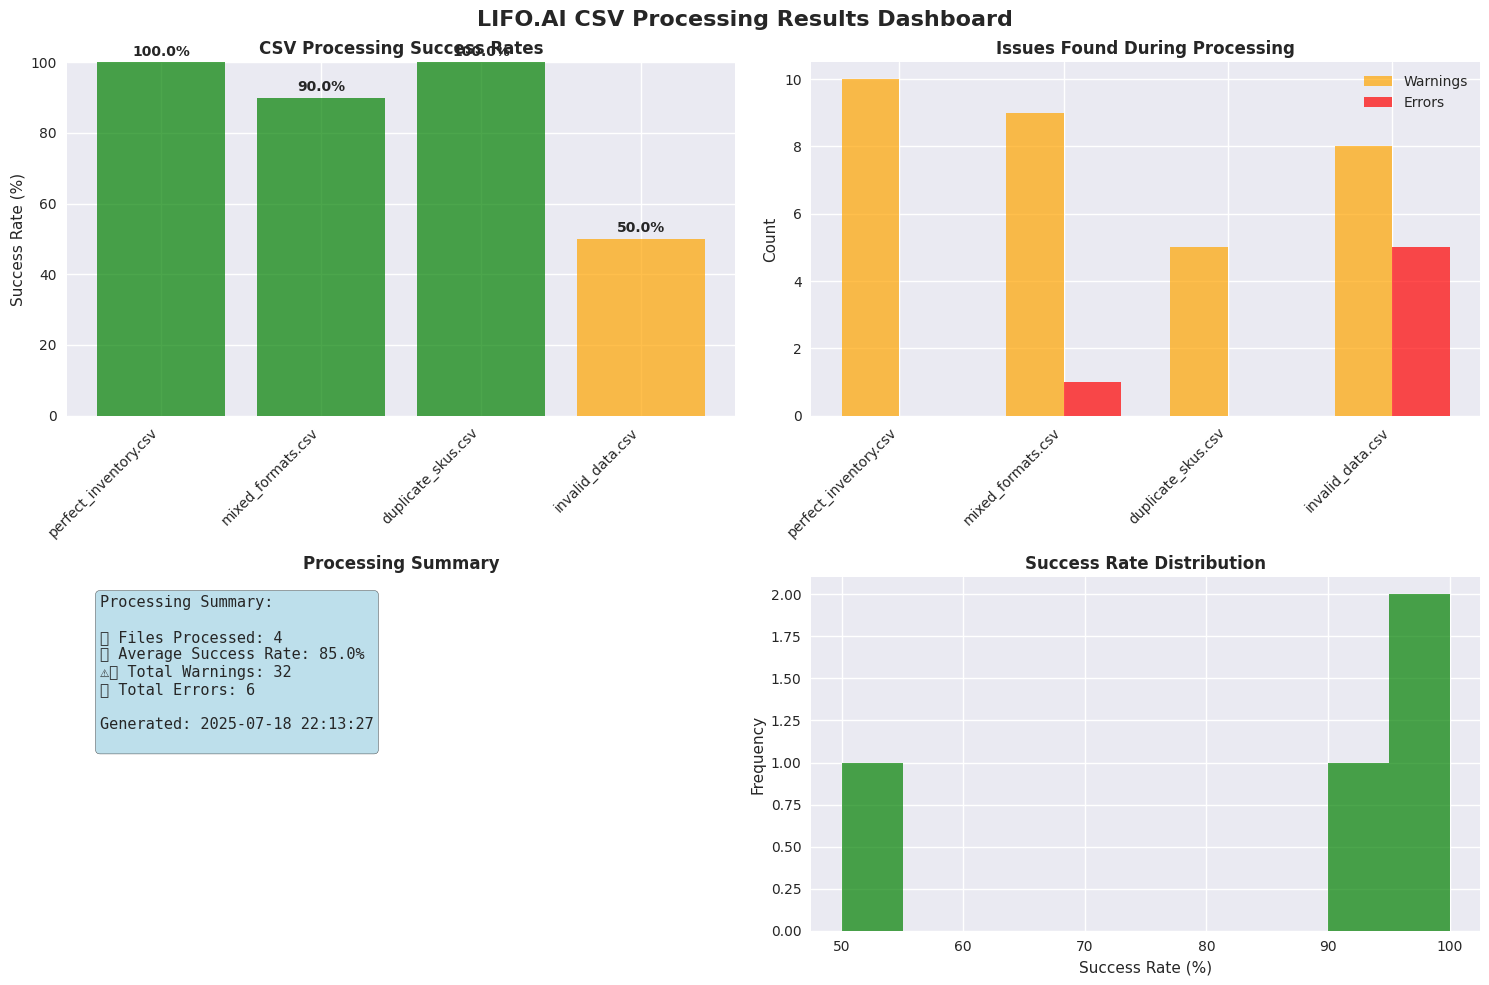


✅ Visualization saved to: ../outputs/visualizations/csv_processing_results.png


In [8]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set up plotting style with compatibility fix
try:
    plt.style.use('seaborn-v0_8')
except:
    # Fallback for older matplotlib versions
    try:
        plt.style.use('seaborn')
    except:
        print("⚠️ Using default matplotlib style")
        
sns.set_palette("husl")

def visualize_processing_results(clean_result, messy_results):
    """Create visualizations of processing results"""
    
    print("\n📊 VISUALIZATION: Processing Results Analysis")
    print("=" * 50)
    
    # Combine results
    all_results = {}
    if clean_result:
        all_results['perfect_inventory.csv'] = clean_result
    
    for k, v in messy_results.items():
        if v and v.get('status') != 'failed':
            all_results[os.path.basename(k)] = v
    
    if not all_results:
        print("❌ No results to visualize")
        return
    
    # Extract metrics
    files = list(all_results.keys())
    success_rates = [result.get('success_rate', 0) for result in all_results.values()]
    warning_counts = [len(result.get('warnings', [])) for result in all_results.values()]
    error_counts = [len(result.get('errors', [])) for result in all_results.values()]
    
    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('LIFO.AI CSV Processing Results Dashboard', fontsize=16, fontweight='bold')
    
    # Success rates
    colors = ['green' if rate >= 80 else 'orange' if rate >= 50 else 'red' for rate in success_rates]
    bars1 = axes[0, 0].bar(range(len(files)), success_rates, color=colors, alpha=0.7)
    axes[0, 0].set_title('CSV Processing Success Rates', fontweight='bold')
    axes[0, 0].set_ylabel('Success Rate (%)')
    axes[0, 0].set_xticks(range(len(files)))
    axes[0, 0].set_xticklabels(files, rotation=45, ha='right')
    axes[0, 0].set_ylim(0, 100)
    
    # Add value labels
    for bar, rate in zip(bars1, success_rates):
        height = bar.get_height()
        axes[0, 0].text(bar.get_x() + bar.get_width()/2., height + 1,
                       f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    # Warning and error counts
    x_pos = np.arange(len(files))
    width = 0.35
    axes[0, 1].bar(x_pos - width/2, warning_counts, width, label='Warnings', color='orange', alpha=0.7)
    axes[0, 1].bar(x_pos + width/2, error_counts, width, label='Errors', color='red', alpha=0.7)
    axes[0, 1].set_title('Issues Found During Processing', fontweight='bold')
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].set_xticks(x_pos)
    axes[0, 1].set_xticklabels(files, rotation=45, ha='right')
    axes[0, 1].legend()
    
    # Summary statistics
    total_files = len(files)
    avg_success = np.mean(success_rates) if success_rates else 0
    total_warnings = sum(warning_counts)
    total_errors = sum(error_counts)
    
    summary_text = f"""Processing Summary:
    
📁 Files Processed: {total_files}
📈 Average Success Rate: {avg_success:.1f}%
⚠️ Total Warnings: {total_warnings}
❌ Total Errors: {total_errors}

Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
"""
    
    axes[1, 0].text(0.05, 0.95, summary_text, transform=axes[1, 0].transAxes, 
                   fontsize=11, verticalalignment='top', fontfamily='monospace',
                   bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    axes[1, 0].set_title('Processing Summary', fontweight='bold')
    axes[1, 0].axis('off')
    
    # Success rate distribution
    if success_rates:
        axes[1, 1].hist(success_rates, bins=10, alpha=0.7, color='green')
        axes[1, 1].set_title('Success Rate Distribution', fontweight='bold')
        axes[1, 1].set_xlabel('Success Rate (%)')
        axes[1, 1].set_ylabel('Frequency')
    
    plt.tight_layout()
    
    # Create outputs directory if it doesn't exist
    os.makedirs('../outputs/visualizations', exist_ok=True)
    
    plt.savefig('../outputs/visualizations/csv_processing_results.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return {
        'total_files': total_files,
        'avg_success_rate': avg_success,
        'total_warnings': total_warnings,
        'total_errors': total_errors
    }

# Create visualizations
if 'clean_result' in locals() and 'messy_results' in locals():
    viz_summary = visualize_processing_results(clean_result, messy_results)
    print("\n✅ Visualization saved to: ../outputs/visualizations/csv_processing_results.png")
else:
    print("⚠️ No results available for visualization. Please run the previous cells first.")

## 5. Demo Completion Summary

Let's summarize what we've accomplished in this demo.

In [ ]:
def generate_demo_summary():
    """Generate a summary of the demo session"""
    
    print("\n🎉 DEMO COMPLETION SUMMARY")
    print("=" * 40)
    
    # Check what we accomplished
    has_clean_result = 'clean_result' in locals() and clean_result is not None
    has_messy_results = 'messy_results' in locals() and messy_results
    has_visualization = 'viz_summary' in locals()
    
    print("✅ ACCOMPLISHED:")
    if has_clean_result:
        print("   • Successfully processed clean CSV data")
    if has_messy_results:
        print(f"   • Processed {len(messy_results)} messy data files")
    if has_visualization:
        print("   • Generated processing visualizations")
    
    print("\n🎯 KEY FEATURES DEMONSTRATED:")
    features = [
        "🛡️ Security validation and error handling",
        "🔄 Intelligent data cleaning and normalization",
        "📊 Comprehensive processing analytics",
        "📈 Interactive visualizations",
        "⚠️ Detailed warning and error reporting"
    ]
    
    for feature in features:
        print(f"   {feature}")
    
    print("\n🚀 NEXT STEPS:")
    print("   📝 Try the API Integration Demo (02_API_Integration_Demo.ipynb)")
    print("   🤖 Explore the Scoring Algorithm Demo (03_Scoring_Algorithm_Demo.ipynb)")
    print("   🔄 Check out the End-to-End Workflow Demo (04_End_to_End_Workflow.ipynb)")
    
    return {
        'clean_processing': has_clean_result,
        'messy_processing': has_messy_results,
        'visualization': has_visualization,
        'demo_complete': True
    }

# Generate summary
demo_summary = generate_demo_summary()
print("\n🎊 CSV Processing Demo completed successfully!")